## Imports

In [46]:
from pathlib import Path

import numpy as np
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from xgboost import XGBClassifier

## Data Processing

### Data Loading

In [47]:
CHANNEL_FILES = [
    "total_acc_x_{}.txt",
    "total_acc_y_{}.txt",
    "total_acc_z_{}.txt",
    "body_gyro_x_{}.txt",
    "body_gyro_y_{}.txt",
    "body_gyro_z_{}.txt",
]

In [48]:
root = Path(r"human+activity+recognition+using+smartphones\UCI HAR Dataset\UCI HAR Dataset")
train_dir = root / "train" / "Inertial Signals"
test_dir = root / "test" / "Inertial Signals"

train_channel_arrays = []
test_channel_arrays = []
for pattern in CHANNEL_FILES:
    train_channel_arrays.append(
        np.loadtxt(train_dir / pattern.format("train"))
    )
    test_channel_arrays.append(
        np.loadtxt(test_dir / pattern.format("test"))
    )
    
# Stack channels
X_train = np.stack(train_channel_arrays, axis=-1)
X_test = np.stack(test_channel_arrays, axis=-1)

y_train = np.loadtxt(root / "train" / "y_train.txt", dtype=int) - 1
y_test = np.loadtxt(root / "test" / "y_test.txt", dtype=int) - 1

In [49]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (7352, 128, 6)
y_train shape: (7352,)
X_test shape: (2947, 128, 6)
y_test shape: (2947,)


In [50]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)   # (7352, 768)
X_test_flat = X_test.reshape(X_test.shape[0], -1)      # (2947, 768)

### Feature Engineering

In [51]:
FS = 50.0  # sampling rate
EPS = 1e-8


def safe_corr(a, b):
    if np.std(a) < EPS or np.std(b) < EPS:
        return 0.0
    return float(np.corrcoef(a, b)[0, 1])


def mad(x):
    med = np.median(x)
    return float(np.median(np.abs(x - med)))


def iqr(x):
    q75, q25 = np.percentile(x, [75, 25])
    return float(q75 - q25)


def sma_xyz(xyz):
    # signal magnitude area over a 3-axis signal
    return float(np.sum(np.abs(xyz)) / xyz.shape[0])


def energy(x):
    return float(np.sum(x ** 2) / len(x))


def spectral_entropy_from_mag(mag):
    p = mag / (np.sum(mag) + EPS)
    return float(-np.sum(p * np.log(p + EPS)))


def mean_frequency(freqs, mag):
    w = mag / (np.sum(mag) + EPS)
    return float(np.sum(freqs * w))


def max_index(mag):
    return int(np.argmax(mag))


def band_energies(mag, splits=(8, 4)):
    """
    Produce multi-resolution band energies from FFT magnitude.
    Example:
      8 equal bands
      4 equal bands
    """
    feats = []
    n = len(mag)

    for num_bands in splits:
        edges = np.linspace(0, n, num_bands + 1, dtype=int)
        for i in range(num_bands):
            band = mag[edges[i]:edges[i + 1]]
            feats.append(float(np.sum(band ** 2)))
    return feats


def ar_coeffs_yule_like(x, order=4):
    """
    Lightweight AR coefficients approximation via linear least squares.
    Returns 4 coefficients, similar in spirit to HAR arCoeff().
    """
    x = np.asarray(x, dtype=np.float64)
    if len(x) <= order:
        return [0.0] * order

    Y = x[order:]
    X = np.column_stack([x[order - k - 1: -k - 1] for k in range(order)])
    coef, *_ = np.linalg.lstsq(X, Y, rcond=None)
    return coef.tolist()


def time_features_1d(x):
    return [
        float(np.mean(x)),
        float(np.std(x)),
        mad(x),
        float(np.max(x)),
        float(np.min(x)),
        energy(x),
        iqr(x),
    ]


def freq_features_1d(x, fs=FS):
    fft_vals = np.fft.rfft(x)
    mag = np.abs(fft_vals)
    freqs = np.fft.rfftfreq(len(x), d=1.0 / fs)

    feats = [
        spectral_entropy_from_mag(mag),
        float(max_index(mag)),
        mean_frequency(freqs, mag),
        float(skew(mag, bias=False)),
        float(kurtosis(mag, bias=False)),
    ]
    feats.extend(band_energies(mag, splits=(8, 4)))
    return feats


def features_for_xyz_block(xyz, include_corr=True):
    """
    xyz shape: (T, 3)
    """
    feats = []

    # Per-axis features
    for i in range(3):
        s = xyz[:, i]
        feats.extend(time_features_1d(s))
        feats.extend(ar_coeffs_yule_like(s, order=4))
        feats.extend(freq_features_1d(s))

    # Block-level features
    mag = np.linalg.norm(xyz, axis=1)
    feats.extend(time_features_1d(mag))
    feats.extend(ar_coeffs_yule_like(mag, order=4))
    feats.extend(freq_features_1d(mag))
    feats.append(sma_xyz(xyz))

    if include_corr:
        feats.extend([
            safe_corr(xyz[:, 0], xyz[:, 1]),
            safe_corr(xyz[:, 0], xyz[:, 2]),
            safe_corr(xyz[:, 1], xyz[:, 2]),
        ])

    return feats


def extract_features(window):
    """
    window shape: (128, 6)
    channels:
      0,1,2 = total_acc_x/y/z
      3,4,5 = gyro_x/y/z
    """
    window = np.asarray(window, dtype=np.float64)

    acc = window[:, :3]
    gyro = window[:, 3:]

    # Jerk signals (first derivative)
    acc_jerk = np.diff(acc, axis=0)
    gyro_jerk = np.diff(gyro, axis=0)

    feats = []

    # Base accel and gyro blocks
    feats.extend(features_for_xyz_block(acc, include_corr=True))
    feats.extend(features_for_xyz_block(gyro, include_corr=True))

    # Jerk blocks
    feats.extend(features_for_xyz_block(acc_jerk, include_corr=True))
    feats.extend(features_for_xyz_block(gyro_jerk, include_corr=True))

    # Cross-block features
    acc_mag = np.linalg.norm(acc, axis=1)
    gyro_mag = np.linalg.norm(gyro, axis=1)
    acc_jerk_mag = np.linalg.norm(acc_jerk, axis=1)
    gyro_jerk_mag = np.linalg.norm(gyro_jerk, axis=1)

    for s in [acc_mag, gyro_mag, acc_jerk_mag, gyro_jerk_mag]:
        feats.extend(time_features_1d(s))
        feats.extend(ar_coeffs_yule_like(s, order=4))
        feats.extend(freq_features_1d(s))

    # A few useful ratios / contrasts for gait separation
    feats.extend([
        float(np.mean(np.abs(acc[:, 2]))),              # vertical-ish accel intensity
        float(np.std(acc[:, 2])),
        float(np.mean(np.abs(gyro[:, 1]))),             # torso pitch/rotation proxy
        float(np.std(gyro[:, 1])),
        float(np.mean(acc_mag) / (np.mean(gyro_mag) + EPS)),
        float(np.mean(acc_jerk_mag)),
        float(np.mean(gyro_jerk_mag)),
    ])

    return np.array(feats, dtype=np.float32)

In [52]:
def transform_dataset(X):
    return np.array([extract_features(x) for x in X])


X_train_feat = transform_dataset(X_train)
X_test_feat = transform_dataset(X_test)

print("Feature shape:", X_train_feat.shape)

Feature shape: (7352, 583)


In [53]:
scaler = StandardScaler()
X_train_feat = scaler.fit_transform(X_train_feat)
X_test_feat = scaler.transform(X_test_feat)

### Explotary Data Analysis

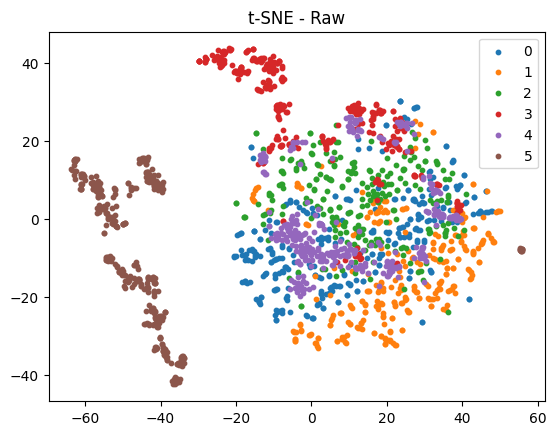

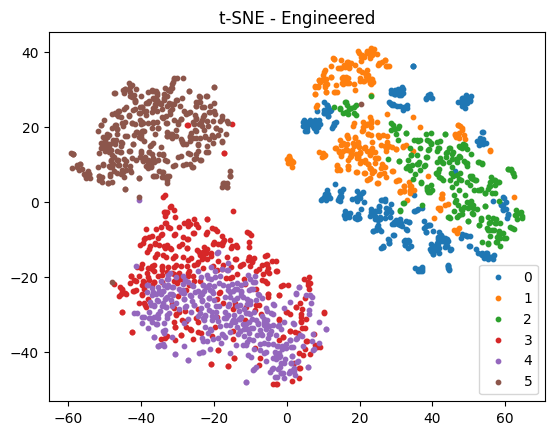

In [54]:
from sklearn.manifold import TSNE

def plot_tsne(X, y, title="t-SNE"):
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    X_tsne = tsne.fit_transform(X)

    plt.figure()
    for label in np.unique(y):
        idx = y == label
        plt.scatter(X_tsne[idx, 0], X_tsne[idx, 1], label=label, s=10)

    plt.legend()
    plt.title(title)
    plt.show()

# Use subset (t-SNE is slow)
idx = np.random.choice(len(X_train_feat), 2000, replace=False)

plot_tsne(X_train_flat[idx], y_train[idx], title="t-SNE - Raw")
plot_tsne(X_train_feat[idx], y_train[idx], title="t-SNE - Engineered")

## Train and Evaluate Model

In [55]:
label_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING",
]

In [56]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)
    print(f"Accuracy: {acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=label_names, digits=4))
    print("Confusion Matrix:")
    print(cm)

    return {
        "name": name,
        "model": model,
        "accuracy": acc,
        "y_pred": y_pred,
        "confusion_matrix": cm,
    }

### Decision Tree

In [57]:
dt_model = DecisionTreeClassifier(
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

In [58]:
nb_model = GaussianNB()

In [59]:
svm_rbf_model = SVC(
    kernel="rbf",
    C=10.0,
    gamma="scale",
    random_state=42
)

In [60]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=6,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

In [61]:
results = []

results.append(
    evaluate_model(
        "Decision Tree",
        dt_model,
        X_train_feat, y_train,
        X_test_feat, y_test
    )
)

results.append(
    evaluate_model(
        "Gaussian Naive Bayes",
        nb_model,
        X_train_feat, y_train,
        X_test_feat, y_test
    )
)

results.append(
    evaluate_model(
        "SVM (RBF)",
        svm_rbf_model,
        X_train_feat, y_train,
        X_test_feat, y_test
    )
)

results.append(
    evaluate_model(
        "XGBoost",
        xgb_model,
        X_train_feat, y_train,
        X_test_feat, y_test
    )
)


Decision Tree
Accuracy: 0.8483

Classification Report:
                    precision    recall  f1-score   support

           WALKING     0.7828    0.8427    0.8117       496
  WALKING_UPSTAIRS     0.7771    0.8365    0.8057       471
WALKING_DOWNSTAIRS     0.8728    0.7190    0.7885       420
           SITTING     0.8484    0.7862    0.8161       491
          STANDING     0.8151    0.8703    0.8418       532
            LAYING     1.0000    1.0000    1.0000       537

          accuracy                         0.8483      2947
         macro avg     0.8494    0.8425    0.8440      2947
      weighted avg     0.8511    0.8483    0.8479      2947

Confusion Matrix:
[[418  48  30   0   0   0]
 [ 63 394  14   0   0   0]
 [ 53  65 302   0   0   0]
 [  0   0   0 386 105   0]
 [  0   0   0  69 463   0]
 [  0   0   0   0   0 537]]

Gaussian Naive Bayes
Accuracy: 0.6457

Classification Report:
                    precision    recall  f1-score   support

           WALKING     0.7636    0.5

In [62]:
print("\nFinal ranking:")
results = sorted(results, key=lambda x: x["accuracy"], reverse=True)

for r in results:
    print(f"{r['name']:20s} -> Accuracy: {r['accuracy']:.4f}")


Final ranking:
SVM (RBF)            -> Accuracy: 0.9396
XGBoost              -> Accuracy: 0.9335
Decision Tree        -> Accuracy: 0.8483
Gaussian Naive Bayes -> Accuracy: 0.6457
